In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

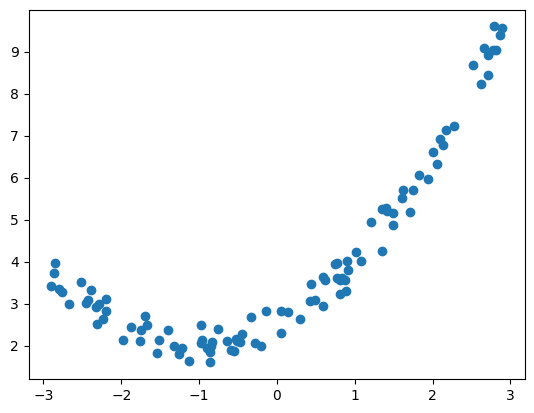

In [2]:
x=6*np.random.rand(100,1)-3
y=0.5*x**2+x+2+np.random.rand(100,1)
plt.scatter(x,y)


In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()
regression_1.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(x_test))
print(score)

0.17028950576165347


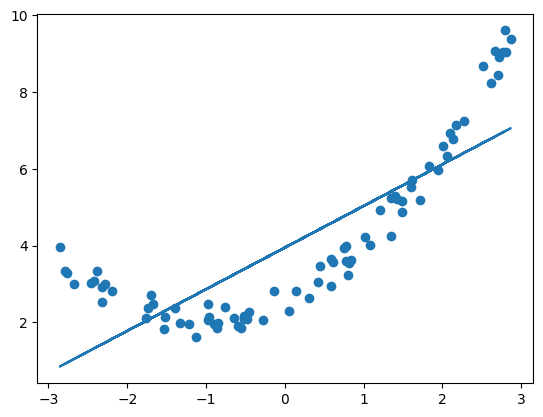

In [8]:
plt.plot(x_train,regression_1.predict(x_train))
plt.scatter(x_train,y_train)

In [9]:
from sklearn.preprocessing import PolynomialFeatures

In [11]:
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [12]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly,y_train)
score=r2_score(y_test,regression.predict(x_test_poly))
print(score)

0.9724559097983159


In [13]:
print(regression.coef_)

[[0.         1.00574324 0.48689015]]


In [14]:
print(regression.intercept_)

[2.55979597]


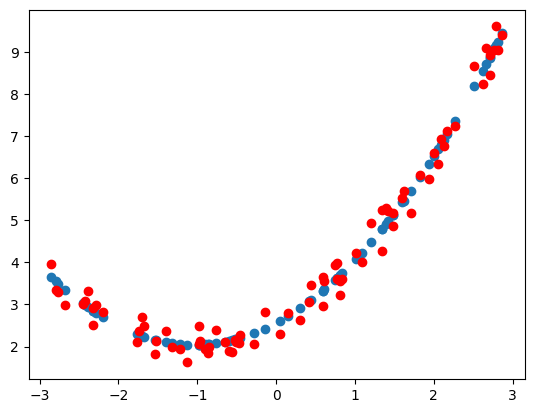

In [22]:
plt.scatter(x_train,regression.predict(x_train_poly))
plt.scatter(x_train,y_train,color='red')

In [24]:
poly=PolynomialFeatures(degree=3,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [25]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly,y_train)
score=r2_score(y_test,regression.predict(x_test_poly))
print(score)

0.9724874615758315


In [26]:
x_new=np.linspace(-3,3,100).reshape(100,1)
x_new_poly=poly.transform(x_new)
x_new_poly.shape

(100, 4)

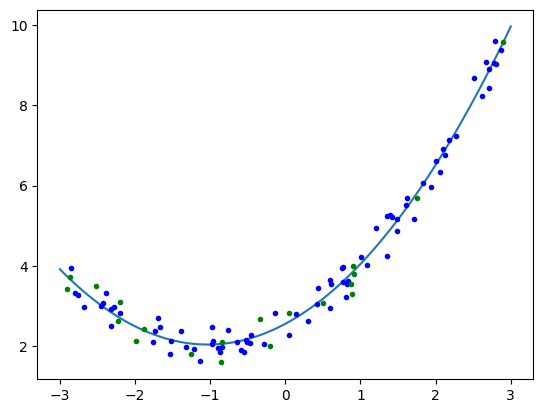

In [29]:
y_new=regression.predict(x_new_poly)
plt.plot(x_new,y_new)
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')


#pipeline concepts

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=True)
    linear_regression = LinearRegression()
    polynomial_regression = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression)
    ])
    polynomial_regression.fit(x_train, y_train)
    y_new = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_new, label=f"Degree {degree}")
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

In [ ]:
polynomial_regression(degree=2)